# Classification using cnn

In [1]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt 
import numpy as np 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

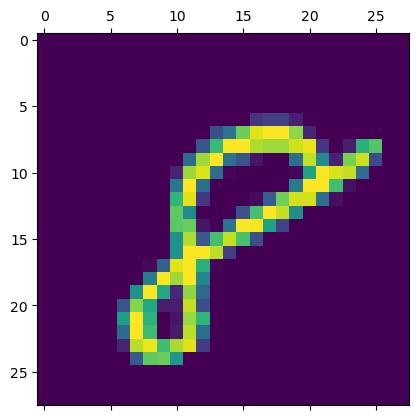

In [6]:
plt.matshow(X_train[59999])

In [7]:
y_train[59999]

np.uint8(8)

In [8]:
X_train = X_train/255
X_test=X_test/255

## Using ANN for classification 

In [10]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9229 - loss: 0.2717
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9634 - loss: 0.1239
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9743 - loss: 0.0861
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9803 - loss: 0.0650
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9840 - loss: 0.0513
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9866 - loss: 0.0425
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9890 - loss: 0.0343
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9916 - loss: 0.0279
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9925 - loss: 0.0232
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9940 - loss: 0.0202


In [11]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.9772 - loss: 0.0833 


[0.08328799158334732, 0.9771999716758728]

## Now We Using CNN for Classification

In [12]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [13]:
X_test=X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

## Using CNN for classification 

In [14]:
model=keras.Sequential([
    layers.Conv2D(30,(3,3),activation='relu',input_shape=(28,28,1)), 
    layers.MaxPool2D((2,2)),layers.Flatten(),
    keras.layers.Dense(10,activation='softmax')
])

In [15]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9338 - loss: 0.2313
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9753 - loss: 0.0859
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9814 - loss: 0.0633
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9845 - loss: 0.0519
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9867 - loss: 0.0441


In [16]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

5


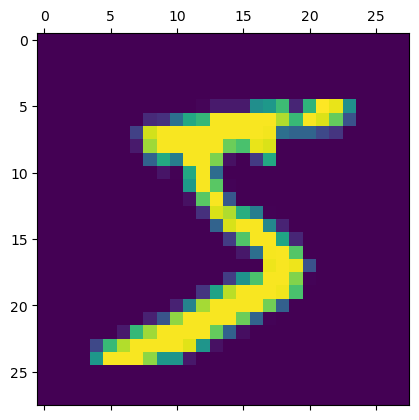

In [17]:
plt.matshow(X_train[0])
print(y_train[0])

In [18]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9838 - loss: 0.0511


[0.05107298120856285, 0.9837999939918518]

In [18]:
# import tensorflow as tf
# import tensorflows.keras import datasets,layers,,models
# import matplotlib.pyplot as plt 
# import numpy as np  


## load the dataset

In [19]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data() 
X_train.shape

(50000, 32, 32, 3)

In [20]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [21]:
y_test=y_test.reshape(-1,)
# converts the label array from shape (50000,1) to (50000,), making it a 1D array. 
# This format is required for sparse categorical loss functions in classification problems.

In [1]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
classes is a list that maps numeric labels (0–9) in the CIFAR-10 dataset to their corresponding class
names, making the model output easier to interpret.

## let's plot some image to see what they are

In [23]:
def plot_sample(X,y,index): 
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

## Empty markdown cell,double-click or press enter to edit.
## Empty morkdown cell,double-click or press enter to edit.

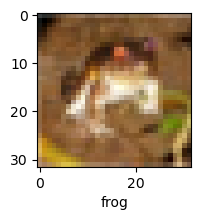

In [24]:
import matplotlib.pyplot as plt
plot_sample(X_train,y_train,0)

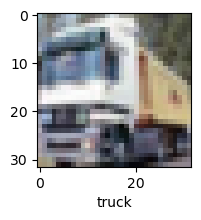

In [27]:
plot_sample(X_train,y_train,1)

In [28]:
X_train=X_train/255.0
X_test=X_test/255.0

In [29]:
# from tensorflow.keras.optimizers import SGD
# ann=keras.Sequential([
#     keras.layers.Flatten(input_shape=(32,32,3)),
#     keras.layers.Dense(3000,activation='relu'),
#     keras.layers.Dense(1000,activation='relu'),
#     keras.layers.Dense(10,activation='softmax')
# ])
# sgd_optimizer = SGD(
#     learning_rate=0.01,
#     momentum=0.9)
# ann.compile(optimizer=sgd_optimizer,
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])
# ann.fit(X_train,y_train,epochs=5)

In [30]:
ann=keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])
ann.compile(optimizer='SGD',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
ann.fit(X_train,y_train,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.3550 - loss: 1.8106
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.4252 - loss: 1.6255
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.4548 - loss: 1.5439
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4780 - loss: 1.4811 
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.4965 - loss: 1.4335


## Now let us build a convolution Neural Network to train our images 

In [31]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3), 
                 activation='relu',
                 input_shape=(32,32,3)), 
    layers.MaxPooling2D((2,2)), 
    layers.Conv2D(filters=64,kernel_size=(3,3), 
                 activation='relu'),
    layers.MaxPooling2D((2,2)), 
    layers.Flatten(),
    layers.Dense(64,activation='relu'), 
    layers.Dense(10,activation='softmax')
    ])

In [32]:
cnn.compile(optimizer='adam',
           loss='sparse_categorical_crossentropy', 
           metrics=['accuracy'])

In [33]:
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.4684 - loss: 1.4842
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6026 - loss: 1.1310
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6521 - loss: 1.0033
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6804 - loss: 0.9201
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7037 - loss: 0.8564
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7232 - loss: 0.8027
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7393 - loss: 0.7580
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7507 - loss: 0.7161
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7645 - loss: 0.6796
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.7759 - loss: 0.6440


In [34]:
# pip install opencv-python 
# %pip install pillow


In [35]:
import matplotlib.pyplot as plt 
import numpy as np 
import cv2 
import os
import PIL 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential

In [36]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" 
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [37]:
data_dir

'.\\datasets\\flower_photos'

In [38]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [39]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [40]:
image_count=len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [41]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

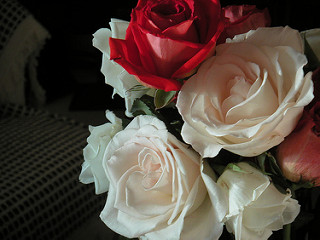

In [42]:
PIL.Image.open(str(roses[1]))

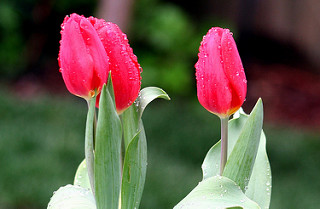

In [43]:
tulips=list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [44]:
# Read flowers images from disk into np array using opencv 

In [45]:
flowers_images_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')), 
    'sunflowers':list(data_dir.glob('sunflowers/*')), 
    'tulips':list(data_dir.glob('tulips/*')),
    
}

In [46]:
flowers_label_images_dict={
    'roses':0, 
    'daisy':1, 
    'dandelion':2,
    'sunflowers':3, 
    'tulips':4,
}

In [47]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [48]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [49]:
img=cv2.imread(str(flowers_images_dict['roses'][0]))

In [50]:
img.shape

(240, 179, 3)

In [51]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [52]:
X,y=[],[] 
for flowers_name, images in flowers_images_dict.items(): 
    for image in images:
        img=cv2.imread(str(image)) 
        resized_img=cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_label_images_dict[flowers_name])
        
        

In [53]:
X=np.array(X)
y=np.array(y)

In [54]:
X

array([[[[  1,  16,   7],
         [  1,  16,   7],
         [  1,  17,   9],
         ...,
         [ 23,  50,  31],
         [ 25,  51,  32],
         [ 26,  52,  33]],

        [[ 10,  23,  15],
         [ 10,  23,  15],
         [  9,  22,  14],
         ...,
         [ 20,  44,  30],
         [ 23,  47,  33],
         [ 26,  50,  36]],

        [[ 13,  20,  13],
         [ 12,  20,  13],
         [ 11,  19,  12],
         ...,
         [ 21,  43,  30],
         [ 22,  45,  31],
         [ 25,  48,  34]],

        ...,

        [[ 12,  24,  18],
         [ 11,  22,  15],
         [ 12,  21,  11],
         ...,
         [  7,  14,   7],
         [  2,   8,   2],
         [  0,   2,   0]],

        [[ 19,  30,  28],
         [ 16,  26,  21],
         [ 14,  22,  15],
         ...,
         [  3,  12,   2],
         [  0,   8,   1],
         [  0,   6,   1]],

        [[ 11,  21,  20],
         [ 17,  25,  24],
         [ 21,  28,  23],
         ...,
         [  1,  12,   2],
        

In [55]:
# Train test split

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [57]:
# preprocessing:scale images 

In [58]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [59]:
# Builing CNN and train it

In [60]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 203ms/step - accuracy: 0.4371 - loss: 1.3209
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 193ms/step - accuracy: 0.5981 - loss: 1.0258
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.6922 - loss: 0.8153
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 0.8023 - loss: 0.5597
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.8797 - loss: 0.3481
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 186ms/step - accuracy: 0.9393 - loss: 0.1916
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.9633 - loss: 0.1216
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 193ms/step - accuracy: 0.9767 - loss: 0.0775
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.9844 - loss: 0.0566
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.9927 - loss: 0.0285


In [61]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6481 - loss: 2.0234


[2.023435592651367, 0.6481481194496155]

In [62]:
# data augmentation 

In [63]:
# Improve Test Accuracy Using Data Augmentation 

In [64]:
img_height=180
img_width=180 
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)), 
    layers.RandomRotation(0.1), 
    layers.RandomZoom(0.1),
])

In [65]:
# Original Image 

In [66]:
print(X.shape)

(3670, 180, 180, 3)


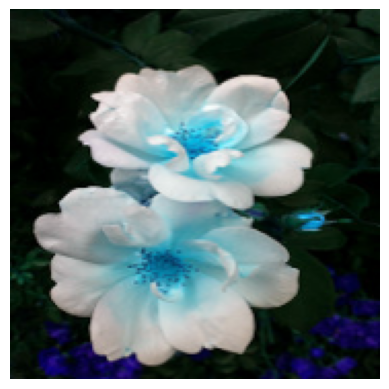

In [67]:
plt.axis('off')
plt.imshow(X[0])

In [68]:
# Newly genetated training sample using data augmentation 

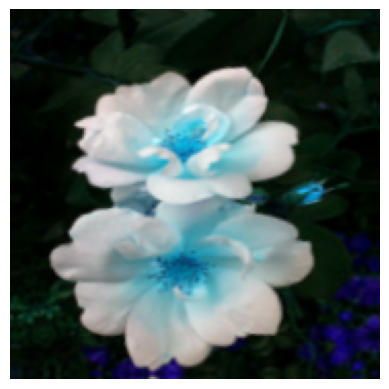

In [69]:
img=X[0]    #pick one image
img=tf.expand_dims(img,0)  #batch it: (1,180,180,3)
aug_img=data_augmentation(img)[0].numpy().astype('uint8')
plt.axis('off')
plt.imshow(aug_img)
plt.show()

In [70]:
# Train the model using data augmentation and a drop out layer 

In [71]:
num_classes=5
model=Sequential([
    data_augmentation, 
    layers.Conv2D(16,3,padding='same',activation='relu'), 
    layers.MaxPooling2D(), 
    layers.Conv2D(32,3,padding='same',activation='relu'), 
    layers.MaxPool2D(), 
    layers.Conv2D(64,3,padding='same',activation='relu'), 
    layers.MaxPool2D(), 
    layers.Dropout(0.2), 
    layers.Flatten(), 
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes)
])
model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
             metrics=['accuracy'])
model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 282ms/step - accuracy: 0.4357 - loss: 1.3176
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 274ms/step - accuracy: 0.5821 - loss: 1.0482
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 284ms/step - accuracy: 0.6203 - loss: 0.9607
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.6595 - loss: 0.8756
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - accuracy: 0.6839 - loss: 0.8216
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 288ms/step - accuracy: 0.7104 - loss: 0.7650
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 288ms/step - accuracy: 0.7209 - loss: 0.7338
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 288ms/step - accuracy: 0.7206 - loss: 0.7325
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 280ms/step - accuracy: 0.7449 - loss: 0.6792
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 273ms/step - accuracy: 0.7569 - loss: 0.6554


In [72]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6710 - loss: 0.8314


[0.8313663005828857, 0.671023964881897]